In [1]:
!pip install pmdarima

In [2]:
!pip install tensorflow

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Stats models
from pmdarima import auto_arima
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

# ML models
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# XGBoost
from xgboost import XGBRegressor

# Scaling
from sklearn.preprocessing import MinMaxScaler

# Deep Learning
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GRU

import warnings
warnings.filterwarnings("ignore")

In [5]:
df = pd.read_csv("P668 DATASET.csv")

In [6]:
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

df.sort_index(inplace=True)

df.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2012-01-03,58.485714,58.928570,58.428570,58.747143,50.765709,75555200
2012-01-04,58.571430,59.240002,58.468571,59.062859,51.038536,65005500
2012-01-05,59.278572,59.792858,58.952858,59.718571,51.605175,67817400
2012-01-06,59.967144,60.392857,59.888573,60.342857,52.144630,79573200
2012-01-09,60.785713,61.107143,60.192856,60.247143,52.061932,98506100


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2011 entries, 2012-01-03 to 2019-12-30
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       2011 non-null   float64
 1   High       2011 non-null   float64
 2   Low        2011 non-null   float64
 3   Close      2011 non-null   float64
 4   Adj Close  2011 non-null   float64
 5   Volume     2011 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 110.0 KB


In [8]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2011 entries, 2012-01-03 to 2019-12-30
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       2011 non-null   float64
 1   High       2011 non-null   float64
 2   Low        2011 non-null   float64
 3   Close      2011 non-null   float64
 4   Adj Close  2011 non-null   float64
 5   Volume     2011 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 110.0 KB


Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

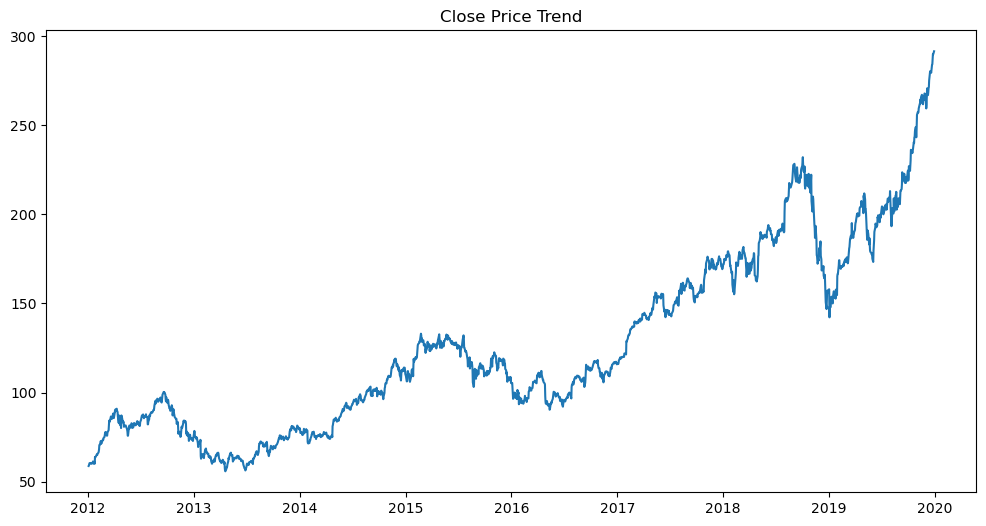

In [9]:
plt.figure(figsize=(12,6))
plt.plot(df['Close'])
plt.title("Close Price Trend")
plt.show()

In [10]:
df['Target'] = df['Close'].shift(-30)
df.dropna(inplace=True)

In [11]:
df['Lag_1'] = df['Close'].shift(1)
df['Lag_2'] = df['Close'].shift(2)
df['Lag_3'] = df['Close'].shift(3)

df.dropna(inplace=True)
df['MA10'] = df['Close'].rolling(10).mean()
df['MA50'] = df['Close'].rolling(50).mean()
df['Volatility'] = df['Close'].rolling(10).std()

df.dropna(inplace=True)

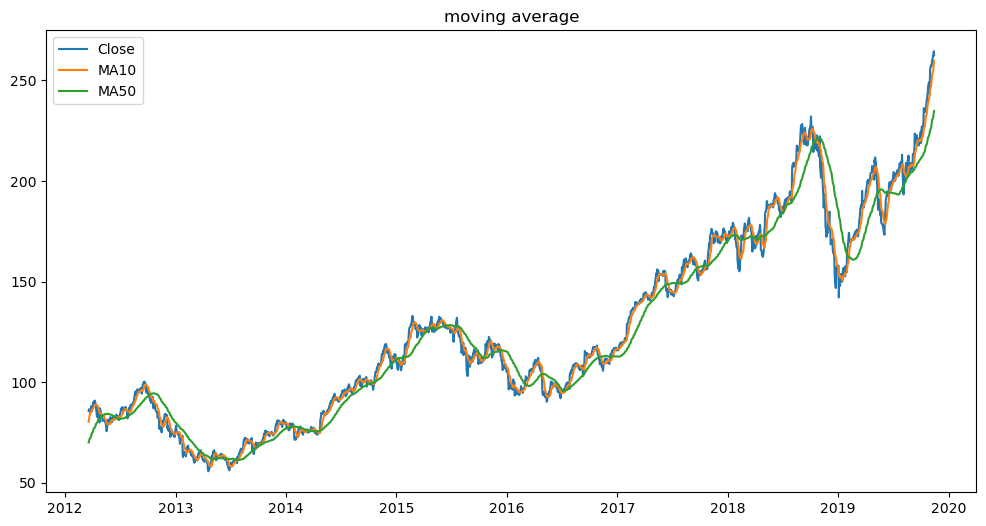

In [12]:
plt.figure(figsize=(12,6))
plt.plot(df['Close'], label='Close')
plt.plot(df['MA10'], label='MA10')
plt.plot(df['MA50'], label='MA50')
plt.legend()
plt.title('moving average')
plt.show()

In [13]:
df.head()

,Open,High,Low,Close,Adj Close,Volume,Target,Lag_1,Lag_2,Lag_3,MA10,MA50,Volatility
Date,,,,,,,,,,,,,
2012-03-19,85.481430,85.967140,84.150002,85.871429,74.204872,225309000,83.161430,83.652855,83.651428,84.225716,80.428857,70.094600,3.749119
2012-03-20,85.644287,86.699997,84.497147,86.565712,74.804832,204165500,83.711426,85.871429,83.652855,83.651428,81.510285,70.619057,3.809211
2012-03-21,86.105713,87.092857,85.915718,86.071426,74.377708,161010500,83.117142,86.565712,85.871429,83.652855,82.536142,71.135543,3.470676
2012-03-22,85.397141,86.357140,85.075714,85.620003,73.987610,155967700,80.750000,86.071426,86.565712,85.871429,83.355428,71.638686,3.075102
2012-03-23,85.784286,85.971428,84.914284,85.150002,73.581444,107622200,81.354286,85.620003,86.071426,86.565712,84.082285,72.134400,2.428510


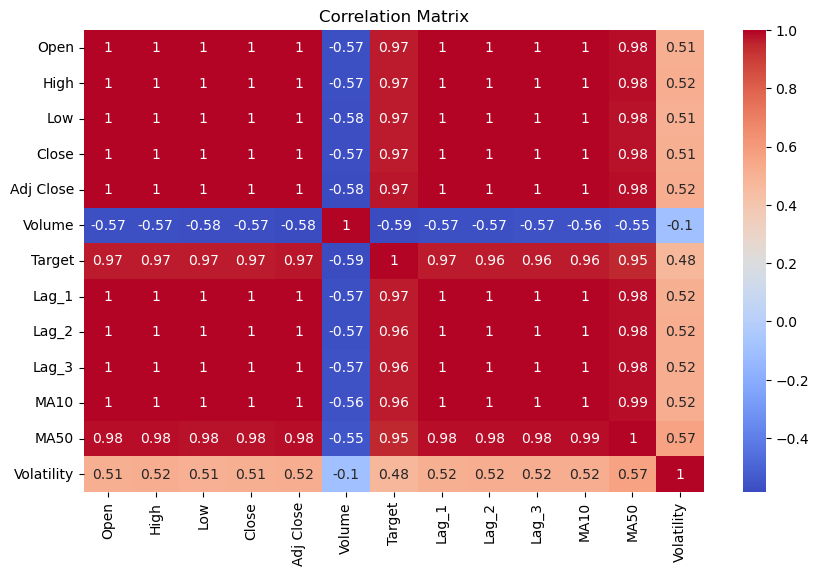

In [14]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [15]:
train_size = int(len(df)*0.8)

train = df[:train_size]
test = df[train_size:]

In [16]:
from pmdarima import auto_arima

auto_model = auto_arima(train['Close'], 
                        seasonal=False,
                        stepwise=True,
                        suppress_warnings=True)

print(auto_model.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1543
Model:               SARIMAX(2, 1, 2)   Log Likelihood               -2967.036
Date:                Thu, 07 May 2026   AIC                           5946.071
Time:                        15:11:34   BIC                           5978.116
Sample:                             0   HQIC                          5957.993
                               - 1543                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.1828      0.126      1.451      0.147      -0.064       0.430
ar.L1         -1.0740      0.078    -13.767      0.000      -1.227      -0.921
ar.L2         -0.7981      0.067    -11.964      0.0

In [17]:
arima_model = ARIMA(train['Close'], order=auto_model.order)
arima_fit = arima_model.fit()
arima_pred = arima_fit.forecast(steps=len(test))
arima_pred = pd.Series(arima_pred.values, index=test.index)

In [18]:
# Fit model
arima_model = ARIMA(train['Close'], order=(5,1,2))
arima_fit = arima_model.fit()

# Forecast
arima_pred = arima_fit.forecast(steps=len(test))

# ✅ FIX: Assign correct index
arima_pred = pd.Series(arima_pred.values, index=test.index)

# Evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_arima = mean_absolute_error(test['Close'], arima_pred)
rmse_arima = np.sqrt(mean_squared_error(test['Close'], arima_pred))

print("MAE:", mae_arima)
print("RMSE:", rmse_arima)

MAE: 22.09724395392629
RMSE: 27.757452695705922


In [19]:
train_size = int(len(df)*0.8)

train = df[:train_size]
test = df[train_size:]

In [20]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import pandas as pd
import matplotlib.pyplot as plt

# Train SARIMA
sarima_model = SARIMAX(train['Close'], order=(1,1,1), seasonal_order=(0,1,1,12))
sarima_fit = sarima_model.fit()

# Forecast
sarima_pred = sarima_fit.forecast(steps=len(test))

# Fix index
sarima_pred = pd.Series(sarima_pred.values, index=test.index)

In [21]:
sarima_model = SARIMAX(train['Close'], order=(1,1,1), seasonal_order=(1,1,1,12))
sarima_fit = sarima_model.fit()

sarima_pred = sarima_fit.forecast(steps=len(test))

mae_sarima = mean_absolute_error(test['Close'], sarima_pred)
rmse_sarima = np.sqrt(mean_squared_error(test['Close'], sarima_pred))

In [22]:
print("MAE:", mae_sarima)
print("RMSE:", rmse_sarima)

MAE: 17.237392322139875
RMSE: 22.105238757177506


In [23]:
df.columns

Index(['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'Target',
       'Lag_1', 'Lag_2', 'Lag_3', 'MA10', 'MA50', 'Volatility'],
      dtype='object')

In [24]:
scaler = MinMaxScaler(feature_range=(0,1))

scaled_data = scaler.fit_transform(df[['Close']])

In [25]:
def create_sequences(data, seq_length=30):
    X, y = [], []
    for i in range(len(data)-seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data)

split = int(0.8 * len(X))

X_train_gru, X_test_gru = X[:split], X[split:]
y_train_gru, y_test_gru = y[:split], y[split:]

In [26]:
model = Sequential()
model.add(GRU(50, return_sequences=False, input_shape=(X_train_gru.shape[1],1)))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')

model.fit(X_train_gru, y_train_gru, epochs=10, batch_size=32)

Epoch 1/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.0154
Epoch 2/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 4.9039e-04
Epoch 3/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 1.8339e-04
Epoch 4/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 1.6910e-04
Epoch 5/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 1.6343e-04
Epoch 6/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 1.5127e-04
Epoch 7/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 1.4439e-04
Epoch 8/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 1.3641e-04
Epoch 9/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 1.3038e-04
Epoch 10/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 1.2508e-04


In [27]:
gru_pred = model.predict(X_test_gru)

gru_pred = scaler.inverse_transform(gru_pred)
y_test_actual = scaler.inverse_transform(y_test_gru)

mae_gru = mean_absolute_error(y_test_actual, gru_pred)
rmse_gru = np.sqrt(mean_squared_error(y_test_actual, gru_pred))

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step


In [28]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_gru = mean_absolute_error(y_test_actual, gru_pred)
rmse_gru = np.sqrt(mean_squared_error(y_test_actual, gru_pred))

print("GRU MAE:", mae_gru)
print("GRU RMSE:", rmse_gru)

GRU MAE: 3.1920927898154847
GRU RMSE: 4.391310683806384


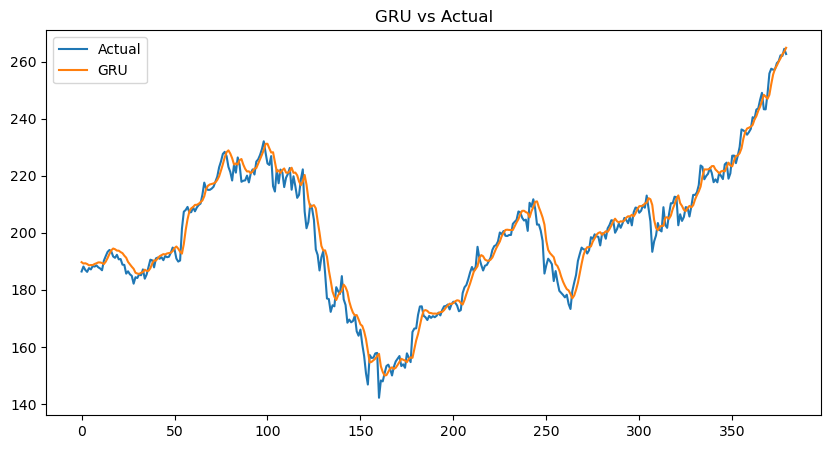

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(y_test_actual, label="Actual")
plt.plot(gru_pred, label="GRU")
plt.legend()
plt.title("GRU vs Actual")
plt.show()

In [30]:
df.columns

Index(['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'Target',
       'Lag_1', 'Lag_2', 'Lag_3', 'MA10', 'MA50', 'Volatility'],
      dtype='object')

In [31]:
features = [
    'Open',
    'High',
    'Low',
    'Volume',
    'Lag_1',
    'Lag_2',
    'Lag_3',
    'MA10',
    'MA50',
    'Volatility'
]

X = df[features]
y = df['Target']
split = int(len(df) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [32]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    min_samples_split=5,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [33]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_rf = mean_absolute_error(y_test, rf_pred)
rmse_rf = np.sqrt(mean_squared_error(y_test, rf_pred))

print("Random Forest MAE:", mae_rf)
print("Random Forest RMSE:", rmse_rf)

Random Forest MAE: 34.937706618716916
Random Forest RMSE: 43.32167132538016


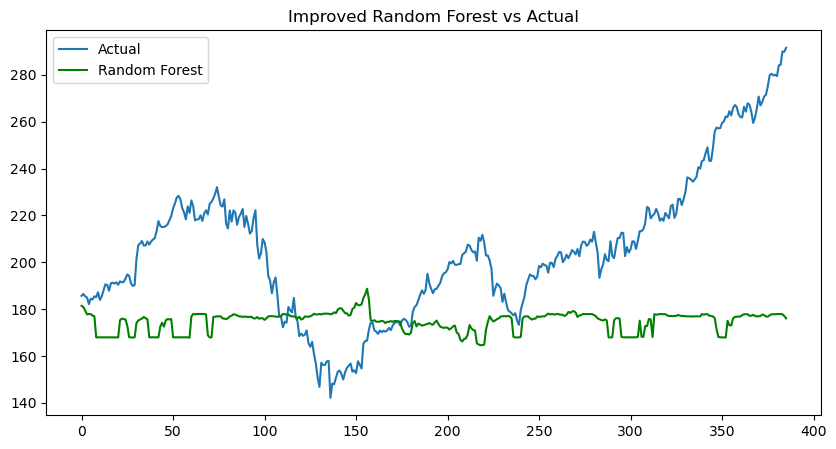

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(y_test.values, label="Actual")
plt.plot(rf_pred, label="Random Forest", color='green')

plt.legend()
plt.title("Improved Random Forest vs Actual")

plt.show()

In [39]:
df.columns

Index(['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'Target',
       'Lag_1', 'Lag_2', 'Lag_3', 'MA10', 'MA50', 'Volatility'],
      dtype='object')

In [40]:

# Features
features = [
    'Open',
    'High',
    'Low',
    'Volume',
    'Lag_1',
    'Lag_2',
    'Lag_3',
    'MA10',
    'MA50',
    'Volatility'
]

# X and y
X = df[features]
y = df['Target']

# Train-test split
split = int(len(df) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [35]:
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [36]:
xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

In [37]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

# Train model
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

xgb.fit(X_train, y_train)

# Predictions
xgb_pred = xgb.predict(X_test)

# Evaluation
mae_xgb = mean_absolute_error(y_test, xgb_pred)
rmse_xgb = np.sqrt(mean_squared_error(y_test, xgb_pred))

print("XGBoost MAE:", mae_xgb)
print("XGBoost RMSE:", rmse_xgb)

XGBoost MAE: 36.653353473387405
XGBoost RMSE: 45.24088362943985


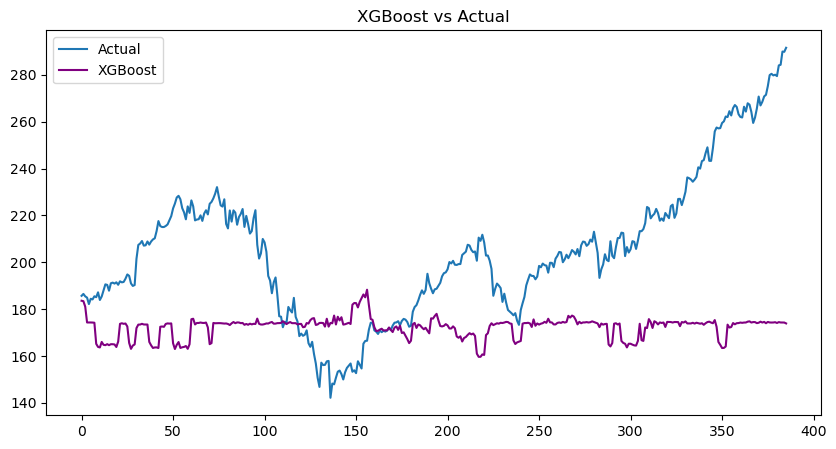

In [38]:
# Plot
plt.figure(figsize=(10,5))

plt.plot(y_test.values, label="Actual")
plt.plot(xgb_pred, label="XGBoost", color='purple')

plt.legend()
plt.title("XGBoost vs Actual")
plt.show()

In [39]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model = Sequential()

model.add(LSTM(
    50,
    return_sequences=False,
    input_shape=(X_train_gru.shape[1], 1)
))

model.add(Dense(1))

model.compile(
    optimizer='adam',
    loss='mse'
)

model.fit(
    X_train_gru,
    y_train_gru,
    epochs=20,
    batch_size=32
)

Epoch 1/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - loss: 0.0157
Epoch 2/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 5.4396e-04
Epoch 3/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 4.0451e-04
Epoch 4/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 3.5814e-04
Epoch 5/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 3.3036e-04
Epoch 6/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 3.2242e-04
Epoch 7/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 3.0340e-04
Epoch 8/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 3.0354e-04
Epoch 9/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 3.0439e-04
Epoch 10/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 2.9293e-04
Epoch 11/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 2.7853e-04
Epoch 12/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 2.7039e-04
Epoch 13/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 2.7445e-04
Epoch 14/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 2.5357e-04
Epoch 15/20
48/48 ━

In [40]:
lstm_pred = model.predict(X_test_gru)

lstm_pred = scaler.inverse_transform(
    lstm_pred.reshape(-1,1)
)

y_test_actual = scaler.inverse_transform(
    y_test_gru.reshape(-1,1)
)

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step


In [41]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_lstm = mean_absolute_error(
    y_test_actual,
    lstm_pred
)

rmse_lstm = np.sqrt(
    mean_squared_error(
        y_test_actual,
        lstm_pred
    )
)

print("LSTM MAE:", mae_lstm)
print("LSTM RMSE:", rmse_lstm)

LSTM MAE: 4.170863152798627
LSTM RMSE: 5.556537471457566


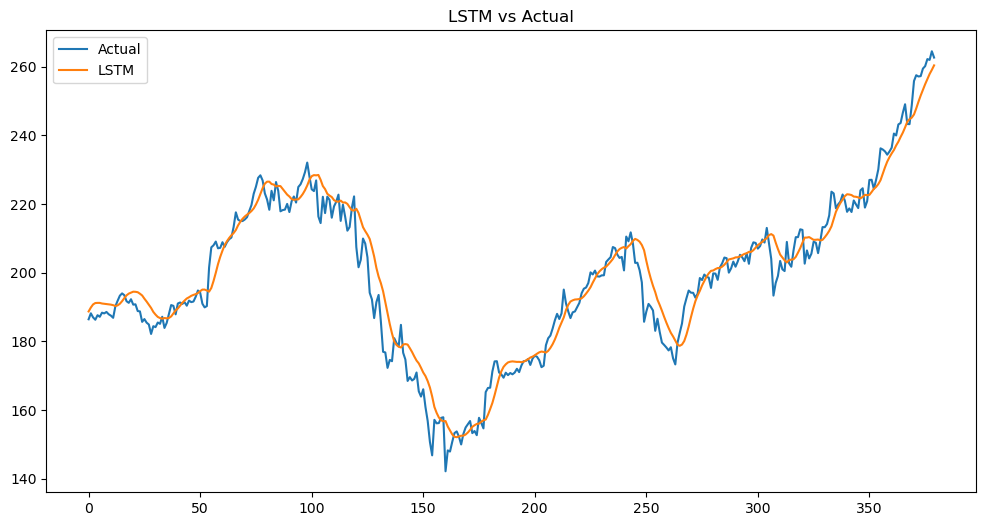

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(y_test_actual, label='Actual')
plt.plot(lstm_pred, label='LSTM')

plt.title("LSTM vs Actual")

plt.legend()
plt.show()

In [43]:
results = pd.DataFrame({
    "Model": ["ARIMA","SARIMA","Random Forest","XGBoost","GRU","LSTM"],
    "MAE": [mae_arima, mae_sarima, mae_rf, mae_xgb, mae_gru,mae_lstm],
    "RMSE": [rmse_arima, rmse_sarima, rmse_rf, rmse_xgb, rmse_gru,rmse_lstm]
})

print(results)

           Model        MAE       RMSE
0          ARIMA  22.097244  27.757453
1         SARIMA  17.237392  22.105239
2  Random Forest  34.937707  43.321671
3        XGBoost  36.653353  45.240884
4            GRU   3.192093   4.391311
5           LSTM   4.170863   5.556537


In [44]:
best_model = results.loc[results['RMSE'].idxmin()]
print("Best Model:")
print(best_model)

Best Model:
Model         GRU
MAE      3.192093
RMSE     4.391311
Name: 4, dtype: object


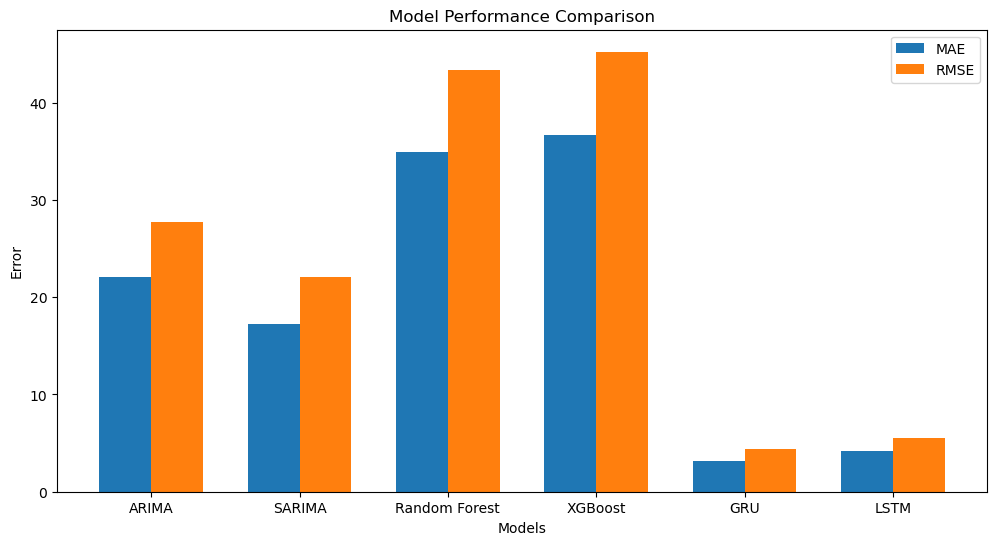

In [45]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(len(results['Model']))
width = 0.35

plt.figure(figsize=(12,6))

plt.bar(x - width/2, results['MAE'], width, label='MAE')
plt.bar(x + width/2, results['RMSE'], width, label='RMSE')

plt.xticks(x, results['Model'])

plt.title("Model Performance Comparison")
plt.xlabel("Models")
plt.ylabel("Error")

plt.legend()

plt.show()

In [46]:
model.save("gru_model.keras")

In [47]:
from tensorflow.keras.models import load_model

model = load_model("gru_model.keras")